In [2]:
import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, roc_auc_score

In [3]:
df = pd.read_csv("dataset/url_features_extracted1.csv")

# pastikan label:
# 1 = legitimate
# 0 = phishing

X = df.drop(['URL', 'ClassLabel'], axis=1)
y = df['ClassLabel']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
print(df['ClassLabel'].unique())
print(df['ClassLabel'].isnull().sum())

[0 1]
0


In [18]:
df = df.dropna(subset=['ClassLabel'])

In [7]:
df['ClassLabel'] = df['ClassLabel'].astype(int)

In [8]:
print("NaN di df:", df['ClassLabel'].isna().sum())
print("Unique:", df['ClassLabel'].unique())

NaN di df: 0
Unique: [0 1]


In [22]:
print("NaN di y_train:", y_train.isna().sum())

NaN di y_train: 0


In [17]:
print("NaN di X_train:", X_train.isna().sum().sum())
print("NaN di y_train:", y_train.isna().sum())

NaN di X_train: 0
NaN di y_train: 1


In [16]:
df = df.reset_index(drop=True)

In [12]:
X = df.drop(['URL', 'ClassLabel'], axis=1)
y = df['ClassLabel']

In [23]:
dt = DecisionTreeClassifier()
rf = RandomForestClassifier(n_estimators=100)
lr = LogisticRegression(max_iter=1000)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Logistic Regression": lr
}

for name, model in models.items():
    print(f"\n{name}")
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12749
           1       1.00      1.00      1.00      7495

    accuracy                           1.00     20244
   macro avg       1.00      1.00      1.00     20244
weighted avg       1.00      1.00      1.00     20244

ROC-AUC: 0.9991958191491271

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12749
           1       1.00      1.00      1.00      7495

    accuracy                           1.00     20244
   macro avg       1.00      1.00      1.00     20244
weighted avg       1.00      1.00      1.00     20244

ROC-AUC: 0.99999757727993

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12749
           1       0.99      1.00      0.99      7495

    accuracy                           1.00     20244
   macro avg       1.00

In [25]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9995554238292828


In [26]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Cross-val mean:", scores.mean())

Cross-val mean: 0.9933313237642197


In [29]:
print(X.columns)

Index(['url_length', 'has_ip_address', 'dot_count', 'https_flag',
       'url_entropy', 'token_count', 'subdomain_count', 'query_param_count',
       'tld_length', 'path_length', 'has_hyphen_in_domain', 'number_of_digits',
       'tld_popularity', 'suspicious_file_extension', 'domain_name_length',
       'percentage_numeric_chars'],
      dtype='object')


In [37]:
pickle.dump(dt, open("model/dt_model.pkl", "wb"))
pickle.dump(rf, open("model/rf_model.pkl", "wb"))
pickle.dump(lr, open("model/lr_model.pkl", "wb"))

In [38]:
import pickle

rf = pickle.load(open("model/rf_model.pkl", "rb"))

In [39]:
url = "https //paskibraka.bpip.go id"

In [42]:
from feature_extraction import extract_features
import numpy as np

features = extract_features(url)
features_array = np.array(features).reshape(1, -1)

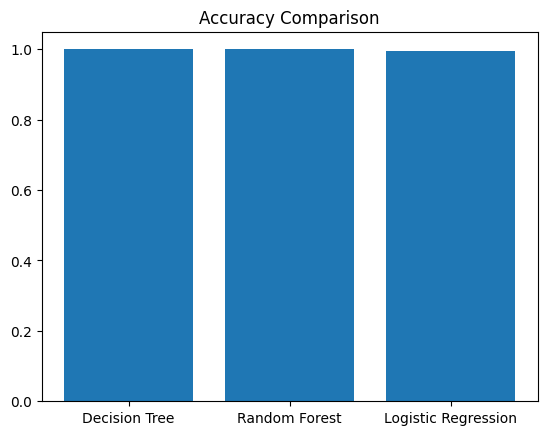

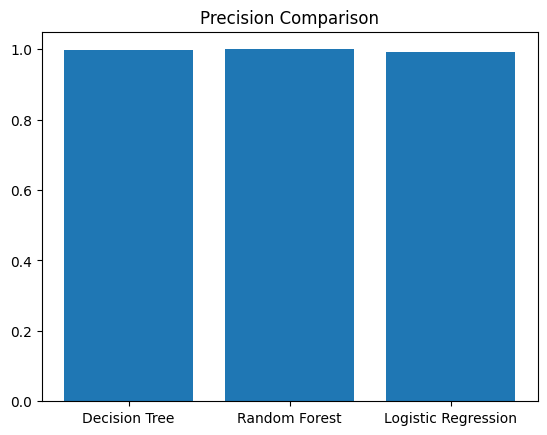

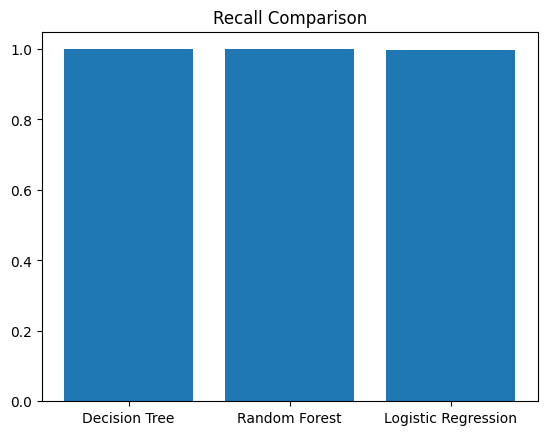

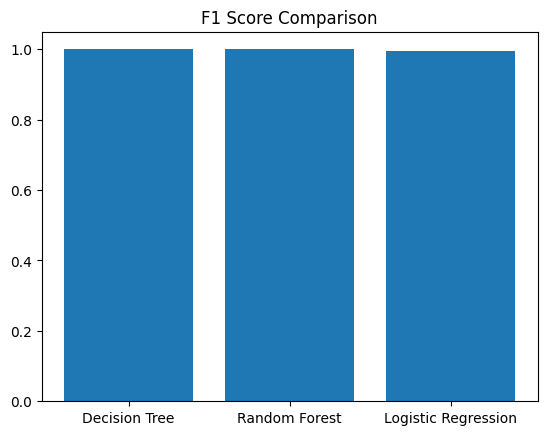

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Logistic Regression": lr
}

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    accuracy_list.append(accuracy_score(y_test, y_pred))
    precision_list.append(precision_score(y_test, y_pred))
    recall_list.append(recall_score(y_test, y_pred))
    f1_list.append(f1_score(y_test, y_pred))

model_names = list(models.keys())

# =========================
# PLOT
# =========================
plt.figure()

plt.bar(model_names, accuracy_list)
plt.title("Accuracy Comparison")
plt.show()

plt.figure()
plt.bar(model_names, precision_list)
plt.title("Precision Comparison")
plt.show()

plt.figure()
plt.bar(model_names, recall_list)
plt.title("Recall Comparison")
plt.show()

plt.figure()
plt.bar(model_names, f1_list)
plt.title("F1 Score Comparison")
plt.show()

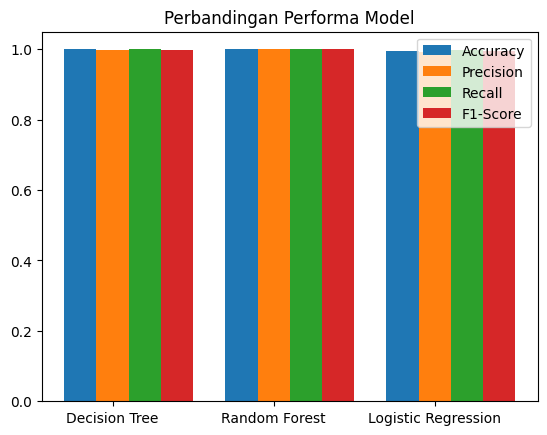

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Logistic Regression": lr
}

metrics = {
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-Score": []
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    
    metrics["Accuracy"].append(accuracy_score(y_test, y_pred))
    metrics["Precision"].append(precision_score(y_test, y_pred))
    metrics["Recall"].append(recall_score(y_test, y_pred))
    metrics["F1-Score"].append(f1_score(y_test, y_pred))

labels = list(models.keys())
x = np.arange(len(labels))
width = 0.2

plt.figure()

plt.bar(x - width, metrics["Accuracy"], width, label="Accuracy")
plt.bar(x, metrics["Precision"], width, label="Precision")
plt.bar(x + width, metrics["Recall"], width, label="Recall")
plt.bar(x + 2*width, metrics["F1-Score"], width, label="F1-Score")

plt.xticks(x, labels)
plt.title("Perbandingan Performa Model")
plt.legend()

plt.show()

In [29]:
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)

In [32]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)

In [31]:
lr = LogisticRegression(C=0.1)

In [33]:
train_test_split(X, y, test_size=0.2, random_state=42)

[       url_length  has_ip_address  dot_count  https_flag  url_entropy  \
 98905          34               0          2           1     4.065260   
 41570          32               1          4           0     3.952820   
 3292           36               1          4           0     4.072431   
 56293          35               1          4           0     3.747439   
 72937          18               0          2           1     3.419382   
 ...           ...             ...        ...         ...          ...   
 6265           33               1          4           0     4.051822   
 54886          28               1          3           0     3.628085   
 76820          29               0          3           1     4.090234   
 860           470               0         14           0     4.585391   
 15795          33               1          4           0     4.006071   
 
        token_count  subdomain_count  query_param_count  tld_length  \
 98905            5                1   

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5
)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=5
)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5)

In [35]:
print("Train:", rf.score(X_train, y_train))
print("Test :", rf.score(X_test, y_test))

Train: 0.9995554128485686
Test : 0.9992096423631693


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

dt = DecisionTreeClassifier()
rf = RandomForestClassifier(n_estimators=100)
lr = LogisticRegression(max_iter=1000)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)

print("Semua model sudah di-fit")

Semua model sudah di-fit


In [38]:
models = {
    "Decision Tree": dt,
    "Random Forest": rf,
    "Logistic Regression": lr
}